In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
df_usd_inr = pd.read_csv("USDINRX.csv")

In [ ]:
df_usd_inr['Date'] = pd.to_datetime(df_usd_inr['Date'])

df_usd_inr = df_usd_inr.sort_values(by='Date')

In [4]:
df_usd_inr.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,4650,4598.000000,4598.000000,4598.000000,4598.000000,4598.000000,4598.0
mean,2012-10-27 11:59:59.999999744,56.113937,56.314436,55.932152,56.115029,56.115029,0.0
min,2003-12-01 00:00:00,38.995998,39.235001,38.979000,39.044998,39.044998,0.0
25%,2008-05-14 06:00:00,45.259998,45.378499,45.165501,45.245750,45.245750,0.0
50%,2012-10-27 12:00:00,54.448000,54.679001,54.265501,54.473000,54.473000,0.0
75%,2017-04-11 18:00:00,66.605049,66.779999,66.410004,66.611500,66.611500,0.0
max,2021-09-24 00:00:00,77.684998,77.754997,76.496300,77.570000,77.570000,0.0
std,NaN,11.384729,11.415379,11.328058,11.398916,11.398916,0.0


In [5]:
df_usd_inr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4650 entries, 0 to 4649
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4650 non-null   datetime64[ns]
 1   Open       4598 non-null   float64       
 2   High       4598 non-null   float64       
 3   Low        4598 non-null   float64       
 4   Close      4598 non-null   float64       
 5   Adj Close  4598 non-null   float64       
 6   Volume     4598 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 254.4 KB


In [6]:
df_usd_inr.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2003-12-01,45.709000,45.728001,45.615002,45.709999,45.709999,0.0
1,2003-12-02,45.709000,45.719002,45.560001,45.629002,45.629002,0.0
2,2003-12-03,45.632000,45.655998,45.474998,45.549999,45.549999,0.0
3,2003-12-04,45.548000,45.612999,45.519001,45.548000,45.548000,0.0
4,2003-12-05,45.549999,45.566002,45.449001,45.449001,45.449001,0.0


In [7]:
df_usd_inr.shape

(4650, 7)

In [8]:
print(f"Number of zeroes in volume column: {(df_usd_inr["Volume"]==0).sum()}")
print(f"unique values in volume column: {df_usd_inr["Volume"].unique()}")

Number of zeroes in volume column: 4598
unique values in volume column: [ 0. nan]


In [9]:
df_usd_inr=df_usd_inr.drop(columns=["Volume"])

In [10]:
df_usd_inr.head()

,Date,Open,High,Low,Close,Adj Close
0,2003-12-01,45.709000,45.728001,45.615002,45.709999,45.709999
1,2003-12-02,45.709000,45.719002,45.560001,45.629002,45.629002
2,2003-12-03,45.632000,45.655998,45.474998,45.549999,45.549999
3,2003-12-04,45.548000,45.612999,45.519001,45.548000,45.548000
4,2003-12-05,45.549999,45.566002,45.449001,45.449001,45.449001


In [11]:
df_usd_inr.isnull().sum()

Date          0
Open         52
High         52
Low          52
Close        52
Adj Close    52
dtype: int64

In [12]:
df_usd_inr.duplicated().sum()

np.int64(0)

In [13]:
df_usd_inr = df_usd_inr.ffill()

In [14]:
df_usd_inr.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64

In [15]:
df_usd_inr.duplicated().sum()

np.int64(0)

In [16]:
((df_usd_inr["Adj Close"]==df_usd_inr["Close"])==False).sum()

np.int64(0)

In [17]:
df_usd_inr=df_usd_inr.drop(columns="Adj Close")

In [18]:
invalid = df_usd_inr[(df_usd_inr['High'] < df_usd_inr['Low']) |
             (df_usd_inr['High'] < df_usd_inr['Open']) |
             (df_usd_inr['High'] < df_usd_inr['Close']) |
             (df_usd_inr['Low'] > df_usd_inr['Open']) |
             (df_usd_inr['Low'] > df_usd_inr['Close'])]

print(invalid)

           Date       Open       High        Low      Close
384  2005-05-20  43.368000  43.507000  43.340000  43.326000
496  2005-10-25  45.049999  45.130001  44.919998  44.900002
719  2006-09-01  46.480000  46.487000  46.415001  46.507999
801  2006-12-26  44.590000  44.590000  44.465000  44.305000
1065 2007-12-31  39.395000  39.419998  39.323002  39.244999
...         ...        ...        ...        ...        ...
4180 2019-12-09  71.272903  71.275002  71.008499  71.286797
4190 2019-12-23  71.050003  71.290497  71.033997  71.024002
4225 2020-02-10  71.504997  71.508003  71.259003  71.515503
4462 2021-01-06  73.167999  73.360001  73.040001  73.374802
4520 2021-03-29  72.447304  72.827400  72.447304  72.447197

[197 rows x 5 columns]


In [19]:
df_usd_inr = df_usd_inr[~(
    (df_usd_inr['High'] < df_usd_inr['Low']) |
    (df_usd_inr['High'] < df_usd_inr['Open']) |
    (df_usd_inr['High'] < df_usd_inr['Close']) |
    (df_usd_inr['Low'] > df_usd_inr['Open']) |
    (df_usd_inr['Low'] > df_usd_inr['Close'])
)]

In [20]:
df_usd_inr.shape

(4453, 5)

In [21]:
#percentage change between current and previous value
df_usd_inr['Returns'] = df_usd_inr['Close'].pct_change()
outliers = df_usd_inr[abs(df_usd_inr['Returns']) > 0.05]
print(outliers)

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Returns]
Index: []


In [22]:
df_usd_inr.head()

,Date,Open,High,Low,Close,Returns
0,2003-12-01,45.709000,45.728001,45.615002,45.709999,NaN
1,2003-12-02,45.709000,45.719002,45.560001,45.629002,-0.001772
2,2003-12-03,45.632000,45.655998,45.474998,45.549999,-0.001731
3,2003-12-04,45.548000,45.612999,45.519001,45.548000,-0.000044
4,2003-12-05,45.549999,45.566002,45.449001,45.449001,-0.002174


## Trend Analysis of Date v/s Exchange Rate

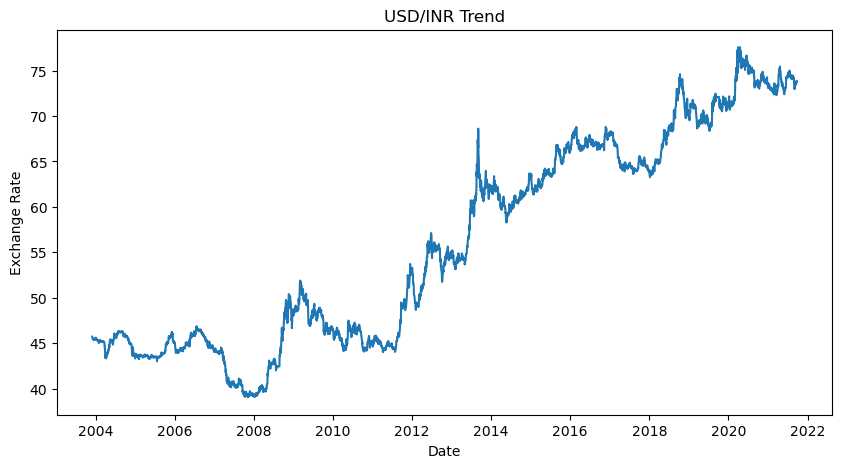

In [23]:
plt.figure(figsize=(10,5))
plt.plot(df_usd_inr['Date'], df_usd_inr['Close'])
plt.title("USD/INR Trend")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

## Moving Average

<Figure size 640x480 with 0 Axes>

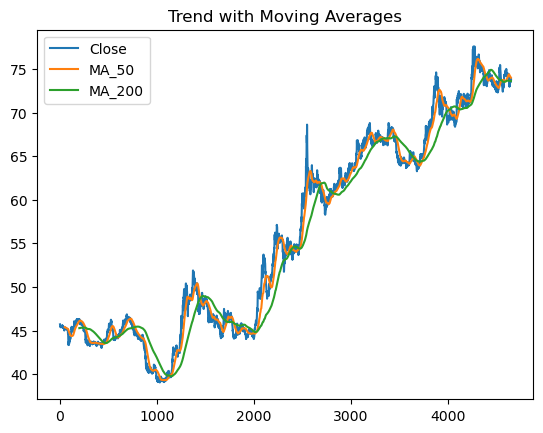

In [24]:
df_usd_inr['MA_50'] = df_usd_inr['Close'].rolling(50).mean()
df_usd_inr['MA_200'] = df_usd_inr['Close'].rolling(200).mean()

plt.figure()
df_usd_inr[['Close','MA_50','MA_200']].plot()
plt.title("Trend with Moving Averages")
plt.show()

=>Since there is an upward trend -> INR is depriciating

## Return Analysis

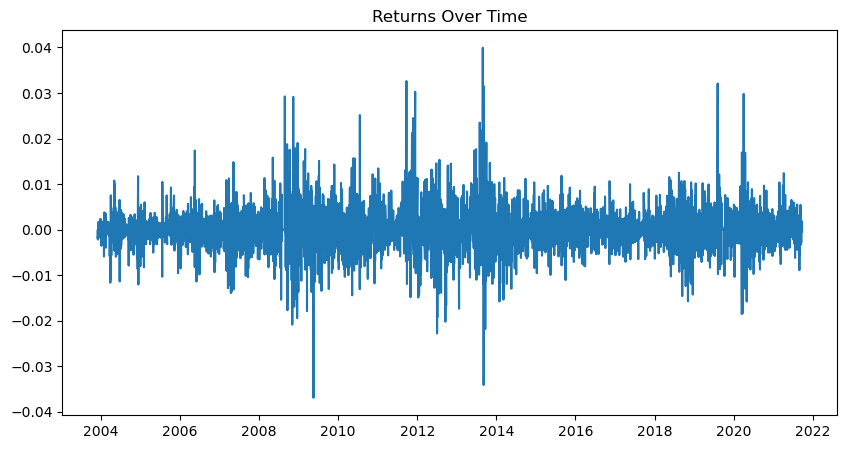

In [25]:
plt.figure(figsize=(10,5))
plt.plot(df_usd_inr['Date'], df_usd_inr['Returns'])
plt.title("Returns Over Time")
plt.show()

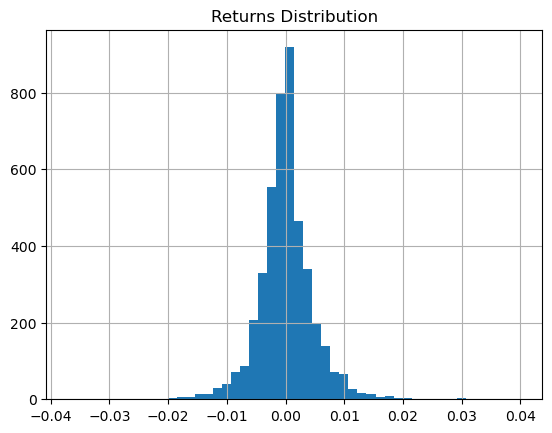

In [26]:
plt.figure()
df_usd_inr['Returns'].hist(bins=50)
plt.title("Returns Distribution")
plt.show()

In [27]:
print(df_usd_inr['Returns'].mean())

0.00011922737377122042


=> Since, mean return > 0:

-> USD is increasing relative to INR

-> INR is depriciating

## VOLATILITY ANALYSIS

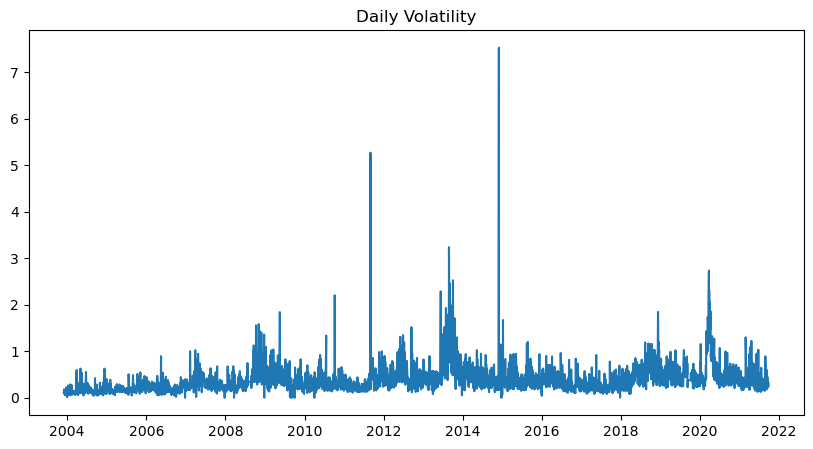

In [28]:
df_usd_inr['Volatility'] = df_usd_inr['High'] - df_usd_inr['Low']

plt.figure(figsize=(10,5))
plt.plot(df_usd_inr['Date'], df_usd_inr['Volatility'])
plt.title("Daily Volatility")
plt.show()

# Outlier Detection

In [29]:
Q1 = df_usd_inr['Volatility'].quantile(0.25)
Q3 = df_usd_inr['Volatility'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_usd_inr[(df_usd_inr['Volatility'] < Q1 - 1.5*IQR) | (df_usd_inr['Volatility'] > Q3 + 1.5*IQR)]

print("Number of outliers:", outliers.shape[0])
print(outliers)

Number of outliers: 233
           Date       Open       High        Low      Close   Returns  \
642  2006-05-17  45.520000  45.520000  44.625000  44.625000 -0.008223   
834  2007-02-09  44.060001  44.119999  43.117001  43.865002 -0.004245   
868  2007-03-29  43.089001  43.735001  42.709999  43.575001  0.011256   
880  2007-04-16  42.365002  42.520000  41.680000  41.775002 -0.013927   
886  2007-04-24  41.573002  41.630001  40.685001  41.013000 -0.013636   
...         ...        ...        ...        ...        ...       ...   
4536 2021-04-20  74.878197  75.724800  74.501999  74.878197  0.004225   
4567 2021-06-02  72.855003  73.434998  72.497803  72.855003  0.005074   
4578 2021-06-17  73.824097  74.238503  73.267998  73.824097  0.006536   
4582 2021-06-23  74.332199  74.544800  73.510803  74.332199  0.002657   
4629 2021-08-27  74.156197  74.330002  73.438004  74.155998  0.000756   

          MA_50     MA_200  Volatility  
642   44.694800  44.597645    0.895000  
834   44.262180  

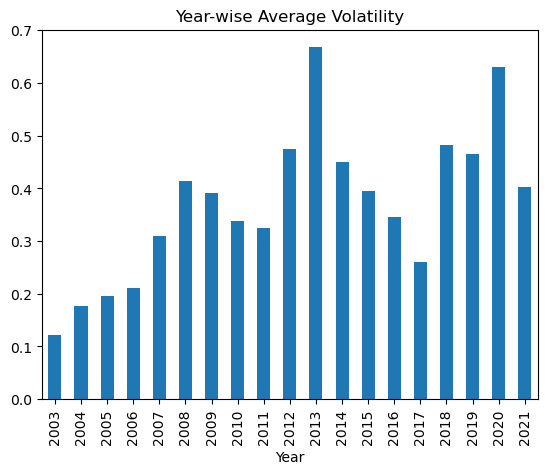

In [37]:
df_usd_inr['Year'] = df_usd_inr['Date'].dt.year
df_usd_inr.groupby('Year')['Volatility'].mean().plot(kind='bar')
plt.title("Year-wise Average Volatility")
plt.show()

=> Therefore, highest volatility was seen in 2014

## Monthly / Yearly Analysis

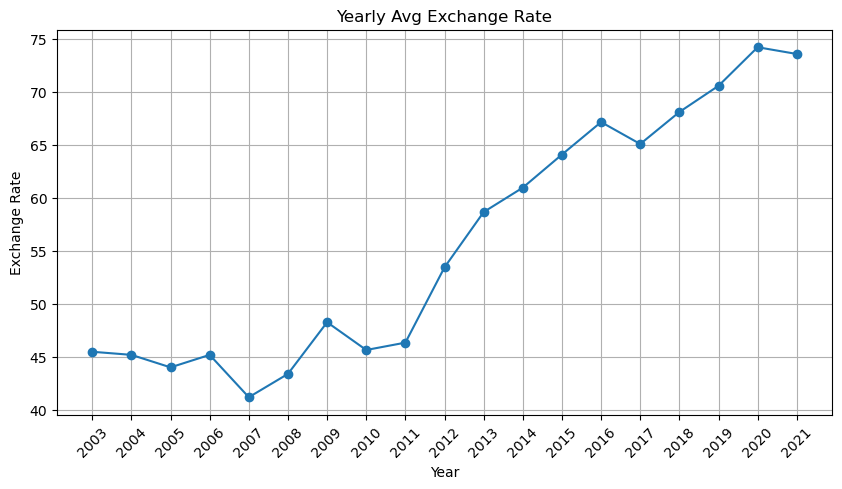

In [38]:
yearly = df_usd_inr.groupby('Year')['Close'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')

plt.xticks(yearly.index.astype(int), rotation=45)

plt.title("Yearly Avg Exchange Rate")
plt.xlabel("Year")
plt.ylabel("Exchange Rate")
plt.grid()
plt.show()

=> As line goes UP:

- USD/INR increasing

- INR is depreciating

# Event Analysis (t-test)

#### COVID (March 2020)

In [33]:
before = df_usd_inr[df_usd_inr['Date'] < '2020-03-01']['Returns'].dropna()
after = df_usd_inr[df_usd_inr['Date'] >= '2020-03-01']['Returns'].dropna()

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 0.19969093856133696
p-value: 0.8418037609323945


=> As, p > 0.05 → no strong statistical difference

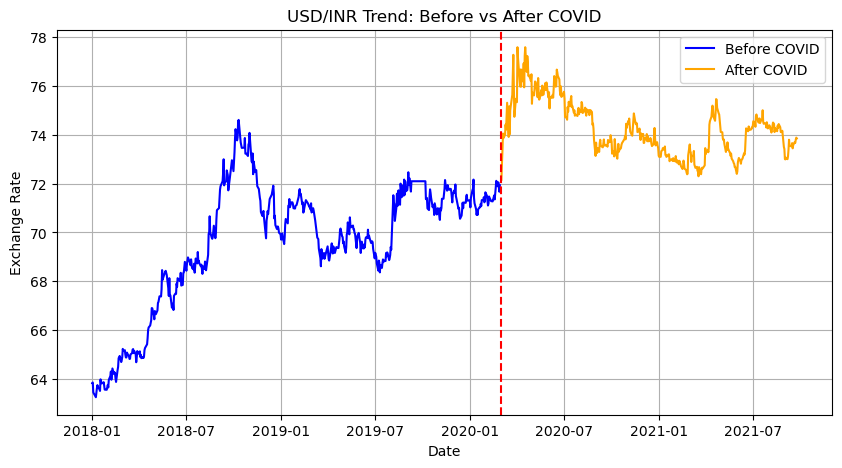

In [34]:
filtered_df = df_usd_inr[(df_usd_inr['Date'] >= '2018-01-01') & (df_usd_inr['Date'] <= '2022-12-31')]

before = filtered_df[filtered_df['Date'] < '2020-03-01']
after = filtered_df[filtered_df['Date'] >= '2020-03-01']

plt.figure(figsize=(10,5))

plt.plot(before['Date'], before['Close'], label='Before COVID', color='blue')
plt.plot(after['Date'], after['Close'], label='After COVID', color='orange')

plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--')

plt.legend()
plt.title("USD/INR Trend: Before vs After COVID")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()

In [35]:
print("Before Mean:", before.mean())
print("After Mean:", after.mean())

Before Mean: Date          2019-02-03 15:46:55.564202240
Open                              69.496812
High                              69.746916
Low                               69.275346
Close                             69.537257
Returns                            0.000236
MA_50                             69.202075
MA_200                            68.228173
Volatility                          0.47157
year                             2018.63035
dtype: object
After Mean: Date          2020-12-12 04:17:38.823529472
Open                              74.240432
High                              74.488273
Low                               73.944863
Close                             74.230424
Returns                            0.000075
MA_50                              74.09134
MA_200                             73.62129
Volatility                         0.543411
year                            2020.463235
dtype: object
